In [1]:
!conda activate pytorch_env

In [2]:
!pip install diffusers

In [3]:
!pip install ucimlrepo

## Библиотеки

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import DDPMScheduler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
from ucimlrepo import fetch_ucirepo 

## Первичные данные

In [5]:
# https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
# data (as pandas dataframes) 
df_1 = magic_gamma_telescope.data.features 
df_2 = magic_gamma_telescope.data.targets 
  
#print(magic_gamma_telescope.variables) 

In [6]:
df_1.columns

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist'],
      dtype='object')

In [7]:
df_2.columns

Index(['class'], dtype='object')

In [8]:
data_df = pd.concat([df_1, df_2], axis=1)
print(f"\n{data_df.head()}")
print(f"\nShape:{data_df.shape}")


    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  

Shape:(19020, 11)


In [9]:
# параметры кластеров на изображениях
X = data_df[data_df.columns[:-1]].values
X = np.abs(X)

# метки классов
labels = data_df[data_df.columns[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [10]:
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [11]:
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [12]:
def plot_hists(X1, X2, label1, label2, names = data_df.columns, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(4 * 4, 4 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.hist(X1[:, i], bins=bins, alpha=0.5, label=label1, color="C0")
        plt.hist(X2[:, i], bins=bins, alpha=0.5, label=label2, color="C1")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

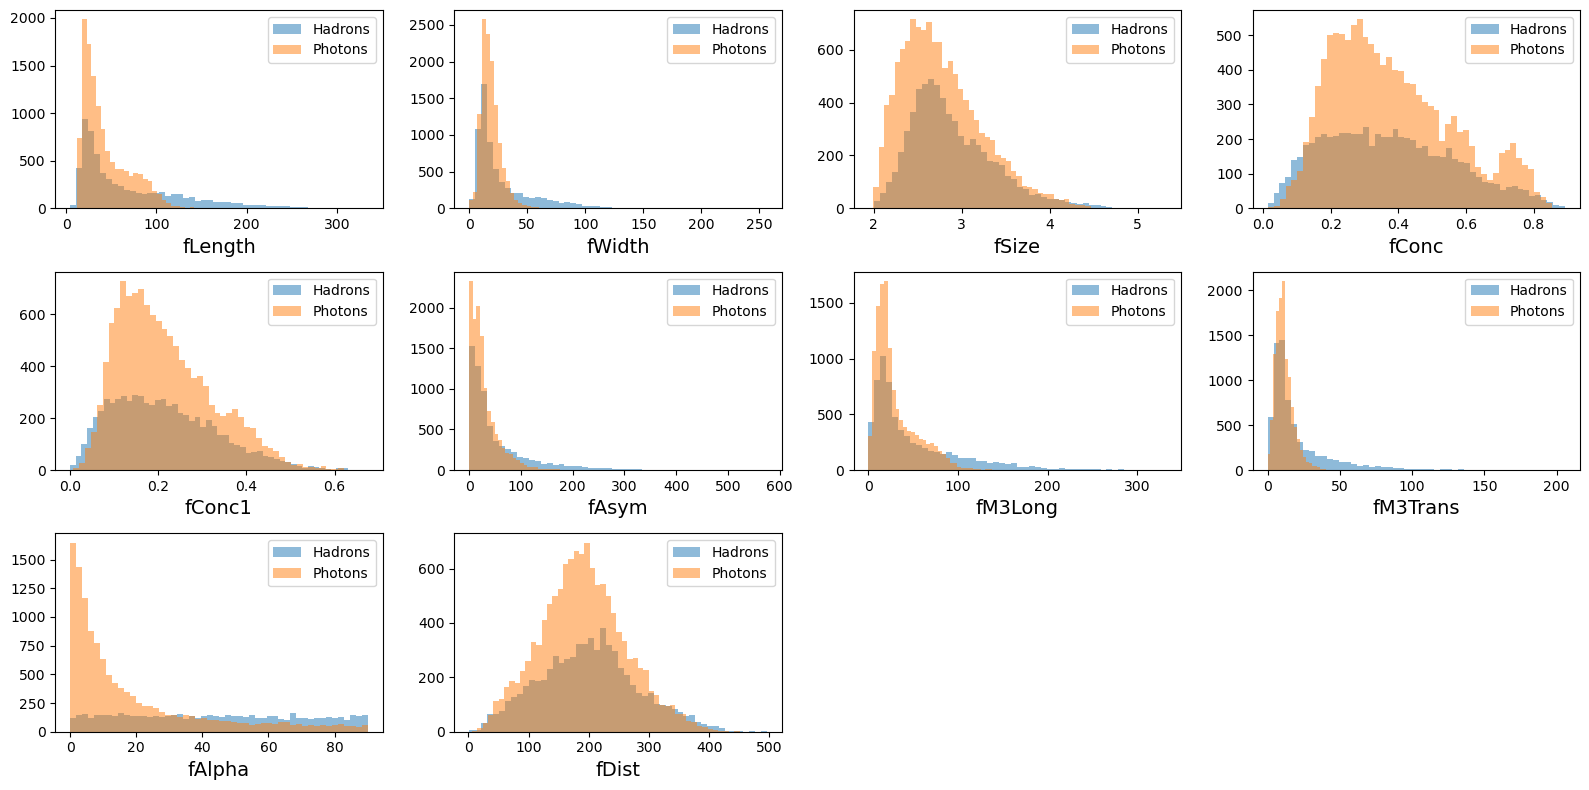

In [13]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1],label1="Hadrons", label2="Photons", names = data_df.columns, bins=50
)

## Предобработка данных

### Задание 1

In [14]:
# output_distribution='normal' ~ Напоминание, не ИИ промт! (Если забуду удалить строку)
qt = QuantileTransformer(output_distribution='normal')
X_qt = qt.fit_transform(X)

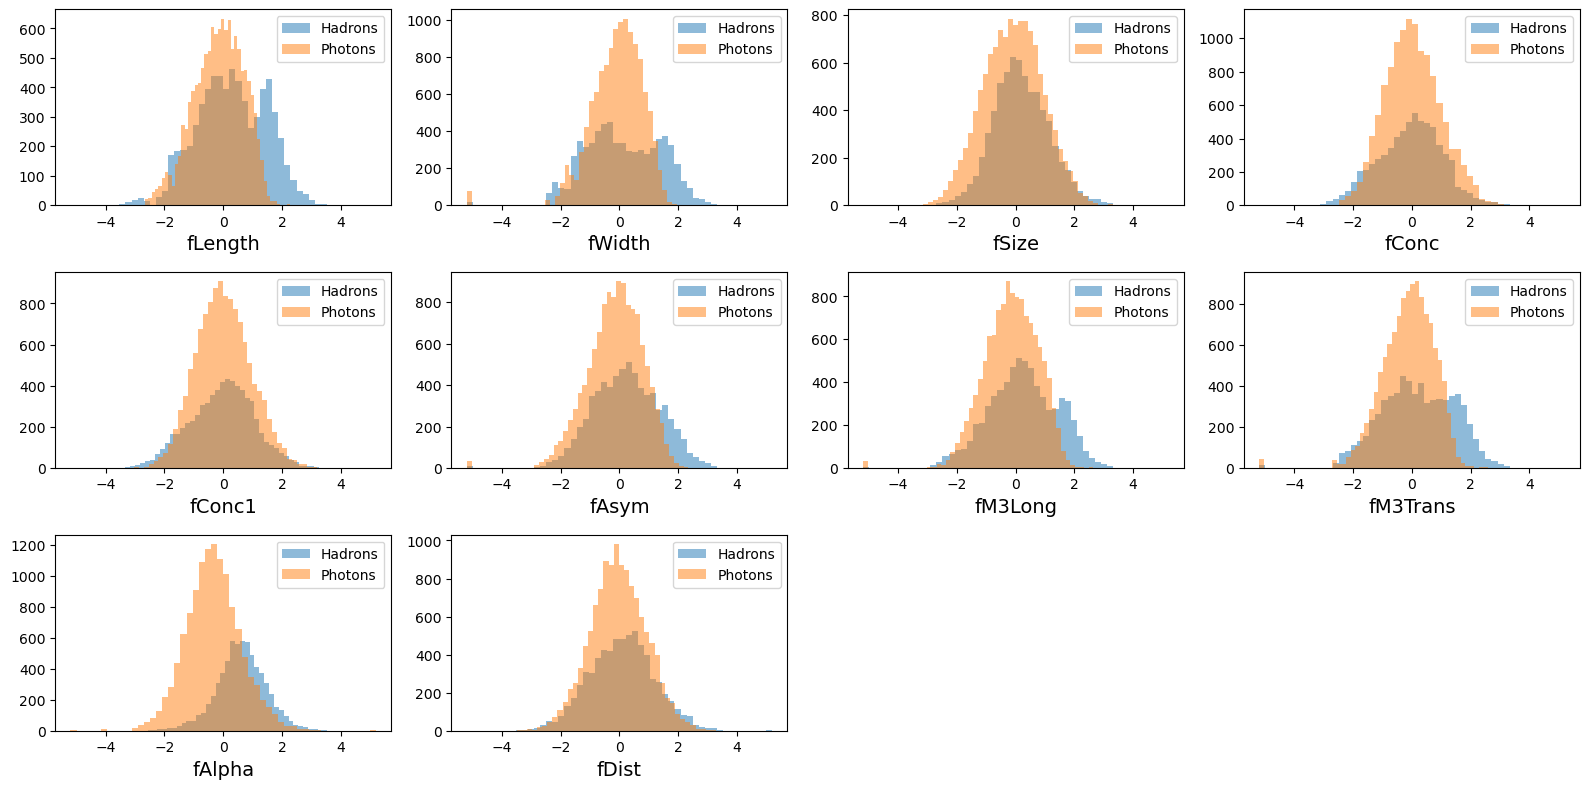

In [15]:
# переусложняю немного из-за не использования names - в которой data_df.columns
plot_hists(
    X_qt[y[:, 0] == 0],
    X_qt[y[:, 0] == 1],
    label1="Hadrons",
    label2="Photons",
    names = data_df.columns,
    bins=50,
)

## Обучающая и тестовая выборки

In [16]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_qt, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)

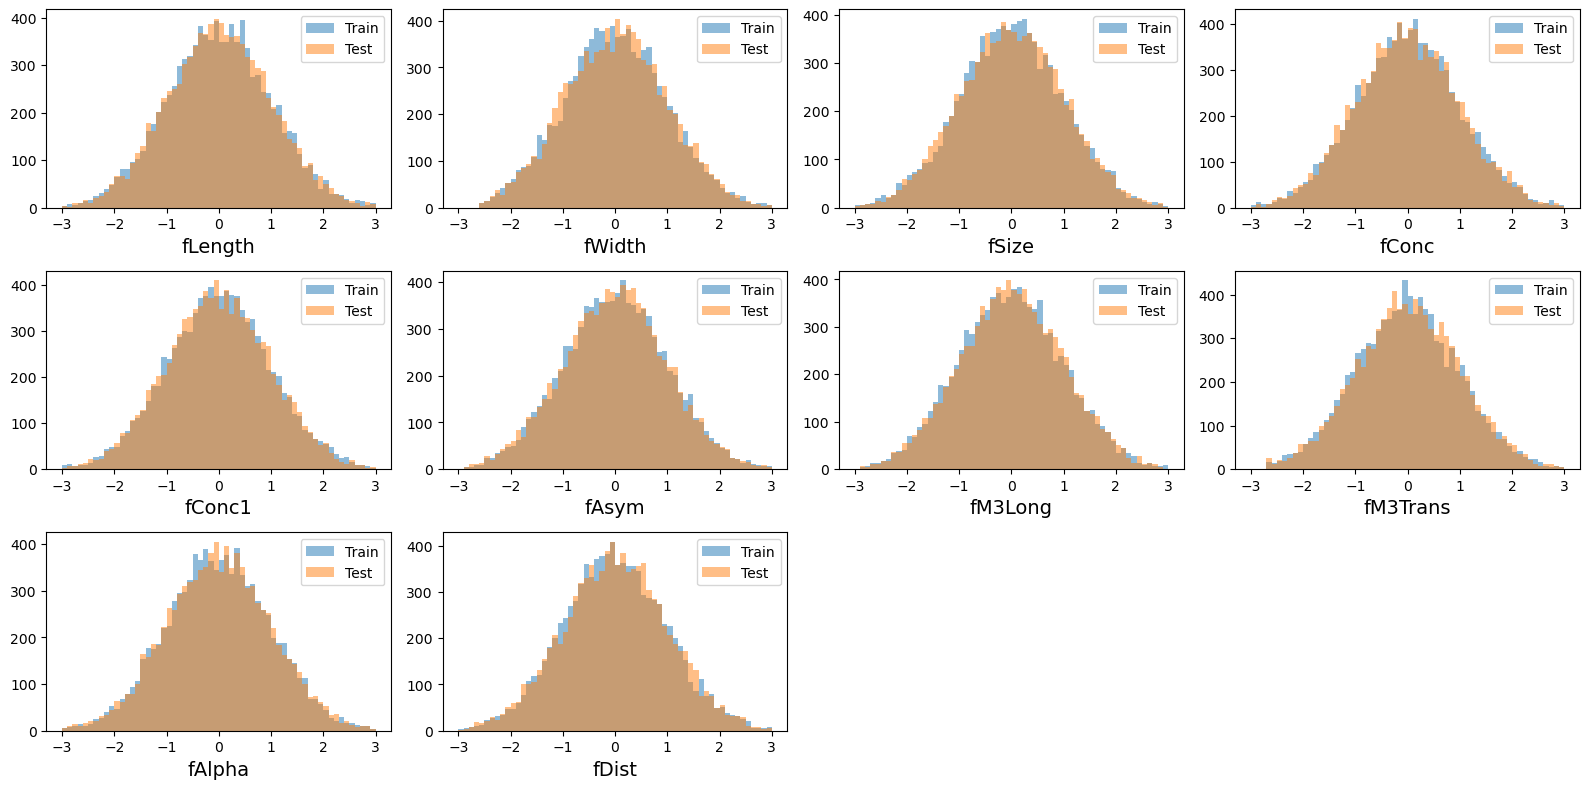

In [17]:
plot_hists(X_train, X_test,label1="Train", label2="Test", names = data_df.columns)

In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"--- GPU {i}: {props.name} ---")
        print(f"Общая память: {props.total_memory / 1024**2:.0f} MB")
        print(f"Вычислительная мощность (Capability): {props.major}.{props.minor}")
        print(f"Количество мультипроцессоров: {props.multi_processor_count}")
else:
    print("CUDA не доступна.")

--- GPU 0: NVIDIA GeForce RTX 4070 Ti SUPER ---
Общая память: 16376 MB
Вычислительная мощность (Capability): 8.9
Количество мультипроцессоров: 66


## Задание 2

In [20]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 3

In [21]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
        )

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.net(xy)

## Задание 4

In [22]:
class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):
        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):

        # numpy to tenso
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in range(self.n_epochs):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                # Дискрим-ор
                self.opt_disc.zero_grad()

                Z_noise = torch.normal(0, 1, (real_batch.size(0), self.latent_dim), device=DEVICE)
                X_fake = self.generator(Z_noise, cond_batch).detach()

                loss_disc = -(torch.mean(self.discriminator(real_batch, cond_batch)) -
                               torch.mean(self.discriminator(X_fake, cond_batch)))
                loss_disc.backward()
                self.opt_disc.step()

                # Ограничение весов (WGAN requirement)
                for p in self.discriminator.parameters():
                    p.data.clamp_(-0.01, 0.01)

                # на n ша-ов обучение 
                if i % self.n_critic == 0:
                    self.opt_gen.zero_grad()

                    Z_noise = torch.normal(0, 1, (real_batch.size(0), self.latent_dim), device=DEVICE)
                    X_fake = self.generator(Z_noise, cond_batch)

                    loss_gen = -torch.mean(self.discriminator(X_fake, cond_batch))
                    loss_gen.backward()
                    self.opt_gen.step()

            # Подсчет loss --<< epoch
            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim), device=DEVICE)
            X_fake = self.generator(Z_noise, y_cond)
            loss_epoch = torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

        # Turn off training
        self.generator.train(False)
        self.discriminator.train(False)

### Обучение

In [23]:
%%time
latent_dim = 15
generator = Generator(n_inputs=latent_dim + y.shape[1], 
                      n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=512,
    n_epochs=120,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
fitter.fit(X_train, y_train)

CPU times: total: 19.7 s
Wall time: 19.7 s


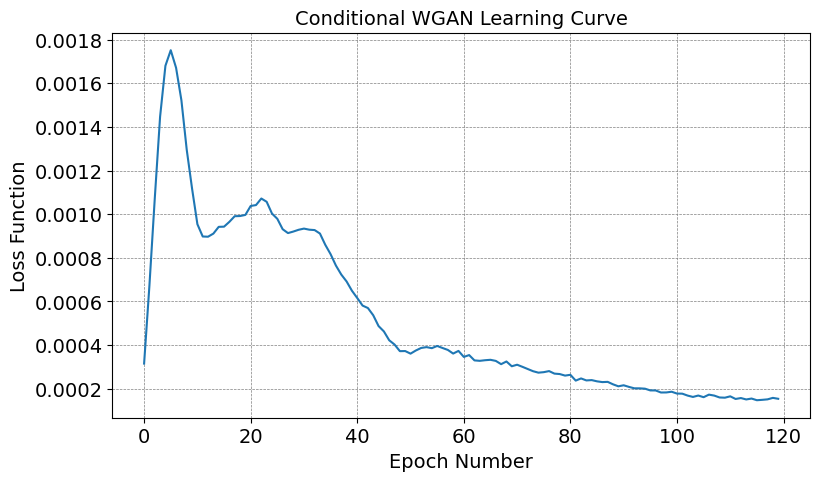

In [24]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 5

In [25]:
def generate(generator, y, latent_dim):
    y_tensor = torch.tensor(y, dtype=torch.float, 
                            device=DEVICE)
    Z_noise = torch.normal(0, 1, (len(y), latent_dim), 
                           device=DEVICE)
    
    with torch.no_grad():
        X_fake = generator(Z_noise, y_tensor)
    
    return X_fake.cpu().numpy()

In [26]:
X_fake_train = generate(fitter.generator, y_train, latent_dim)

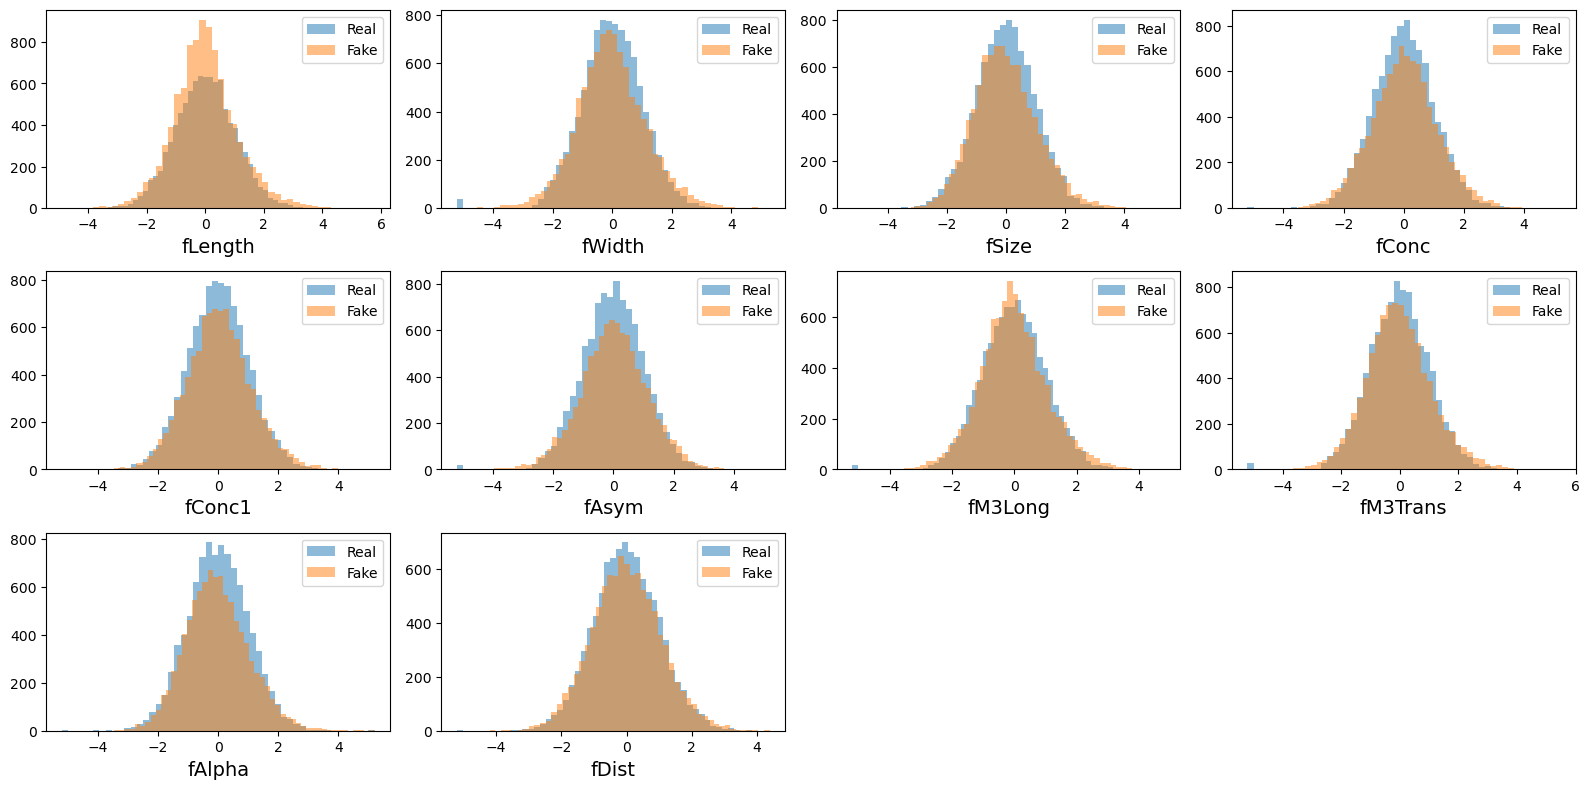

In [27]:
plot_hists(X_train, X_fake_train, label1="Real", label2="Fake",names=data_df.columns, bins=50)

In [28]:
X_fake_test = generate(fitter.generator, y_test, latent_dim)

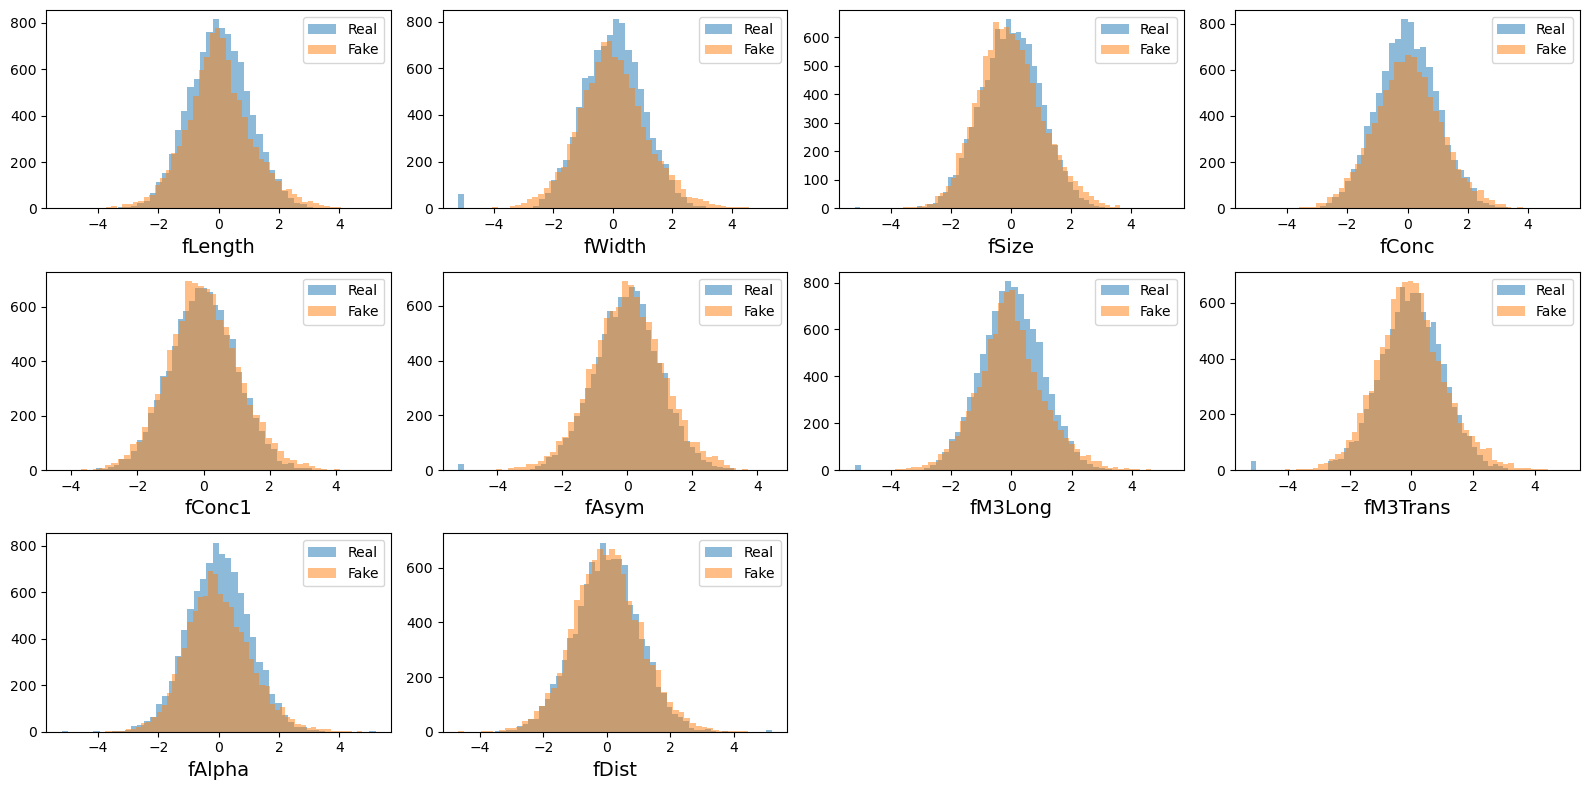

In [29]:
plot_hists(X_test, X_fake_test,label1="Real", label2="Fake",names=data_df.columns, bins=50)

### Измерение качества генерации

In [30]:
# собираем реальную и фейковую матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [31]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [32]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.8091674655379637


## Задание 6

In [33]:
class Encoder(nn.Module):
    def __init__(self, n_inputs, lat_size):
        super().__init__()

        self.enc_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
        )

        self.mu = nn.Linear(100, lat_size)
        self.log_sigma = nn.Linear(100, lat_size)

    def forward(self, x, y):
        z = torch.cat((x, y), dim=1)
        z = self.enc_net(z)
        mu = self.mu(z)
        log_sigma = self.log_sigma(z)
        return mu, log_sigma

## Задание 7

In [34]:
class Decoder(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.dec_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )

    def forward(self, z, y):
        z_cond = torch.cat((z, y), dim=1)
        x_rec = self.dec_net(z_cond)
        return x_rec

## Задание 8

In [35]:
class VAEFitter:
    def __init__(
        self,
        encoder,
        decoder,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        KL_weight=0.001,
    ):
        self.encoder = encoder
        self.decoder = decoder
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.KL_weight = KL_weight

        self.criterion = nn.MSELoss()
        self.opt = torch.optim.RMSprop(
            list(self.encoder.parameters()) + list(self.decoder.parameters()),
            lr=self.lr,
        )

        self.encoder.to(DEVICE)
        self.decoder.to(DEVICE)

    def sample_z(self, mu, log_sigma):
        eps = torch.randn(mu.shape).to(DEVICE)
        return mu + torch.exp(log_sigma / 2) * eps

    def custom_loss(self, x, rec_x, mu, log_sigma):
        KL = torch.mean(
            -0.5 * torch.sum(1 + log_sigma - mu**2 - log_sigma.exp(), dim=1), dim=0
        )
        recon_loss = self.criterion(x, rec_x)
        return KL * self.KL_weight + recon_loss

    def compute_loss(self, x_batch, cond_batch):
        mu, log_sigma = self.encoder(x_batch, cond_batch)
        z = self.sample_z(mu, log_sigma)
        rec_x = self.decoder(z, cond_batch)
        loss = self.custom_loss(x_batch, rec_x, mu, log_sigma)
        return loss

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.encoder.train(True)
        self.decoder.train(True)

        self.loss_history = []

        # Fit VAE --< Gan
        for epoch in range(self.n_epochs):
            for i, (x_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                # calculate loss
                loss = self.compute_loss(x_batch, cond_batch)

                # optimization step
                self.opt.zero_grad()
                loss.backward()
                self.opt.step()

            # calculate and store loss after an epoch
            loss_epoch = self.compute_loss(X_real, y_cond)
            self.loss_history.append(loss_epoch.detach().cpu())

        # Turn off training
        self.encoder.train(False)
        self.decoder.train(False)

### Обучение

In [36]:
%%time

latent_dim = 10

encoder = Encoder(n_inputs=X_train.shape[1] + y.shape[1], lat_size=latent_dim)
decoder = Decoder(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

vae_fitter = VAEFitter(
    encoder,
    decoder,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.001,
    KL_weight=0.001,
)
vae_fitter.fit(X_train, y_train)

CPU times: total: 1min 33s
Wall time: 1min 34s


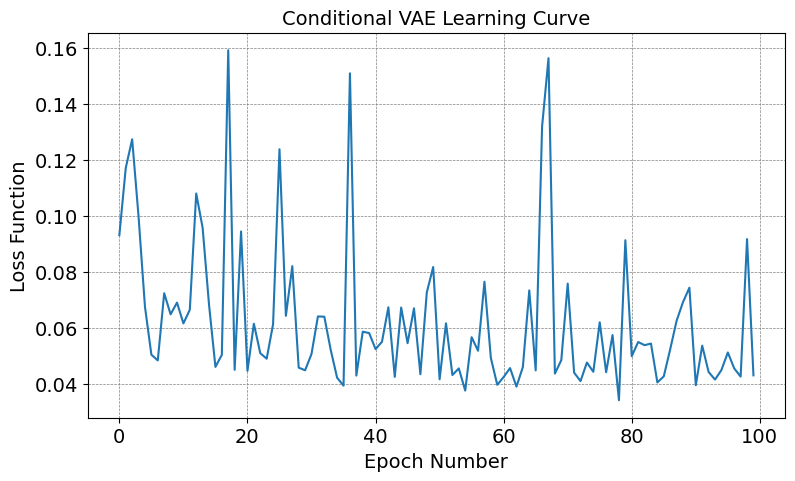

In [37]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(vae_fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional VAE Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 9

In [38]:
def generate(decoder, y, latent_dim):
    y_tensor = torch.tensor(y, dtype=torch.float, device=DEVICE)
    z = torch.randn(len(y), latent_dim, device=DEVICE)
    
    with torch.no_grad():
        X_fake = decoder(z, y_tensor)
    
    return X_fake.cpu().numpy()

In [39]:
X_fake_train = generate(vae_fitter.decoder, y_train, latent_dim)

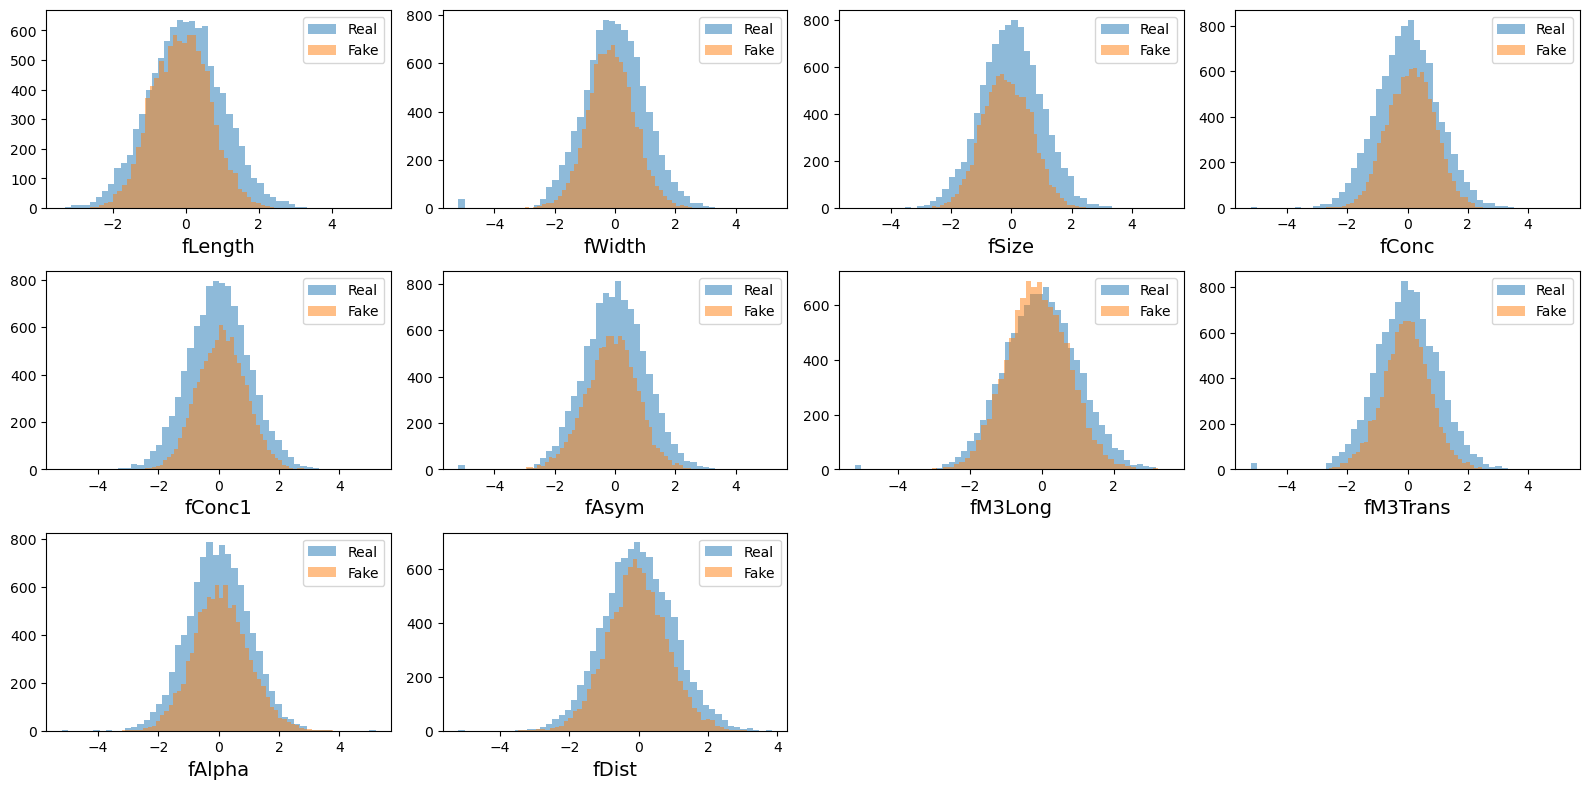

In [40]:
plot_hists(X_train, X_fake_train, label1="Real", label2="Fake",names=data_df.columns, bins=50)

In [41]:
X_fake_test = generate(vae_fitter.decoder, y_test, latent_dim)

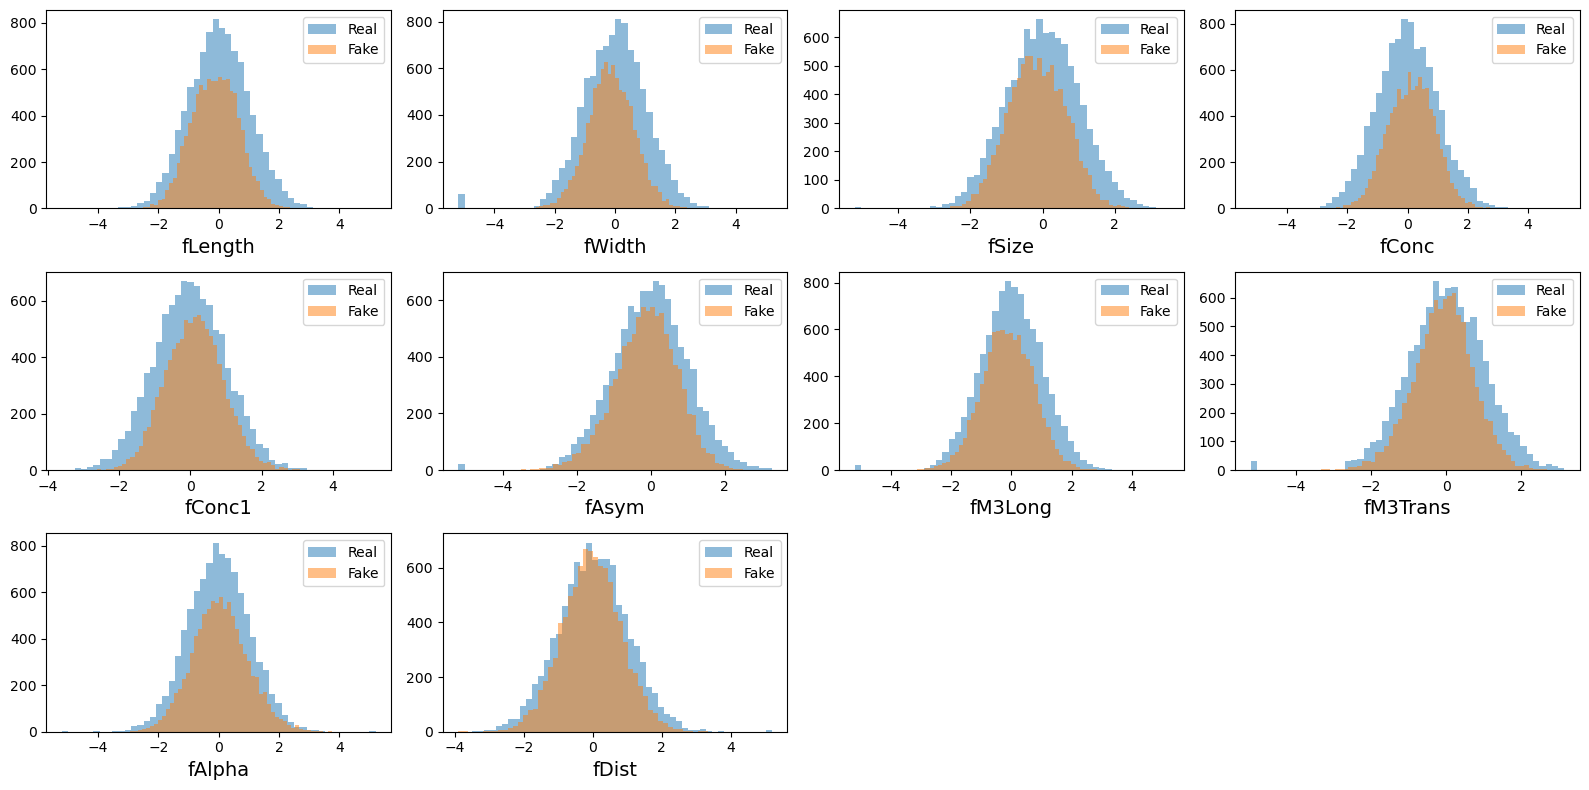

In [42]:
plot_hists(X_test, X_fake_test, label1="Real", label2="Fake",names=data_df.columns, bins=50)

In [43]:
# собираем реальную и фейковую матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [44]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [45]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6901937138503828


In [46]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Задание 10

In [47]:
def corrupt(x, amount):
    t = (amount * (noise_scheduler.num_train_timesteps - 1)).long()
    noise = torch.randn_like(x)
    sqrt_alpha = noise_scheduler.alphas_cumprod[t] ** 0.5
    sqrt_one_minus_alpha = (1 - noise_scheduler.alphas_cumprod[t]) ** 0.5
    sqrt_alpha = sqrt_alpha.view(-1, 1).to(x.device)
    sqrt_one_minus_alpha = sqrt_one_minus_alpha.view(-1, 1).to(x.device)
    x = sqrt_alpha * x + sqrt_one_minus_alpha * noise
    return x

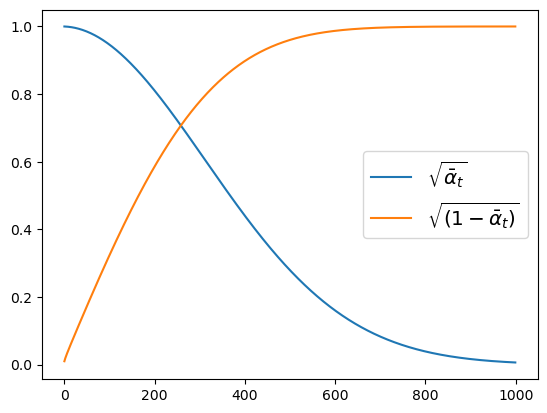

In [48]:
# linear для данных вида таблицы (или похижих?)
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    beta_start=0.0001,
    beta_end=0.02,
)
plt.plot(
    noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$"
)
plt.plot(
    (1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5,
    label=r"$\sqrt{(1 - \bar{\alpha}_t)}$",
)
plt.legend(fontsize="x-large")

## Задание 11

In [49]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 12

In [50]:
def generate_with_diffusion(model, y, latent_dim, sheduler):
    y_tensor = torch.tensor(y, dtype=torch.float, device=DEVICE)
    X_fake = torch.randn(len(y), latent_dim, device=DEVICE)
    # T до 0
    for t in sheduler.timesteps:
        t_batch = torch.full((len(y),), t, device=DEVICE, dtype=torch.long)
        t_norm = (t_batch / sheduler.num_train_timesteps).float().view(-1, 1)
        
        with torch.no_grad():
            noise_pred = model(X_fake, y_tensor)
        
        X_fake = sheduler.step(noise_pred, t, X_fake).prev_sample
    
    return X_fake.cpu().numpy()

## Задание 13

In [51]:
class DiffusionFitter:
    def __init__(
        self,
        model,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):
        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)
        self.criterion = nn.MSELoss()  # добавили criterion

        self.model.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit
        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                amount = torch.rand(real_batch.shape[0], device=DEVICE)

                # шум -->
                t = (amount * (noise_scheduler.num_train_timesteps - 1)).long().cpu()
                noise = torch.randn_like(real_batch)
                sqrt_alpha = (noise_scheduler.alphas_cumprod[t] ** 0.5).view(-1, 1).to(DEVICE)
                sqrt_one_minus = ((1 - noise_scheduler.alphas_cumprod[t]) ** 0.5).view(-1, 1).to(DEVICE)
                noisy_batch = sqrt_alpha * real_batch + sqrt_one_minus * noise

                amount_cond = torch.cat([cond_batch, amount.view(-1, 1)], dim=1)

                # <-- Модель предсказывает оригинальные данные из зашумлённых
                pred = self.model(noisy_batch, amount_cond)

                # MSE между предсказанием и оригиналом
                loss = self.criterion(pred, real_batch)

                self.opt_gen.zero_grad()
                loss.backward()
                self.opt_gen.step()

                loss_epoch += loss.item()

            # Среднее loss за эпоху
            self.loss_history.append(loss_epoch / len(dataset_real) * self.batch_size)

        # Turn off training
        self.model.train(False)

In [52]:
%%time
latent_dim = X_train.shape[1]  

model = DiffusionGenerator(
    n_inputs=latent_dim + y_train.shape[1] + 1,
    n_outputs=latent_dim,
)

diffusionFitter = DiffusionFitter(
    model,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
diffusionFitter.fit(X_train, y_train)

C:\Users\B-ZONE\anaconda3\Lib\site-packages\diffusers\configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


CPU times: total: 1min 1s
Wall time: 1min 1s


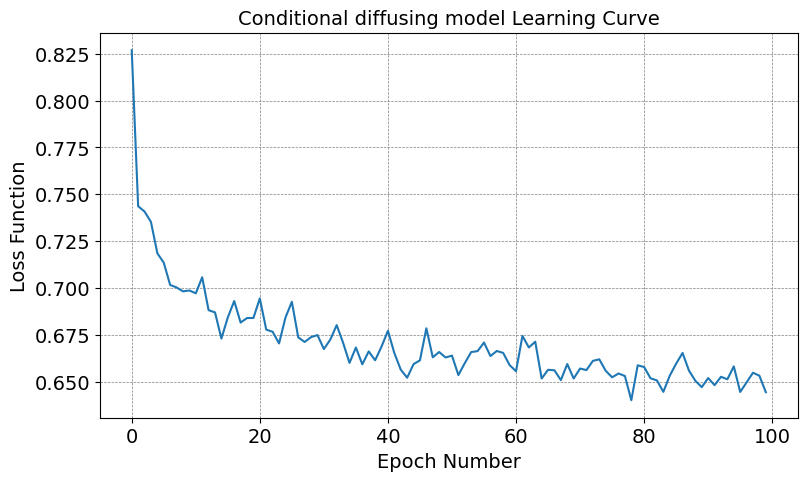

In [53]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 14

In [54]:
X_fake_train = generate(vae_fitter.decoder, y_train, latent_dim)

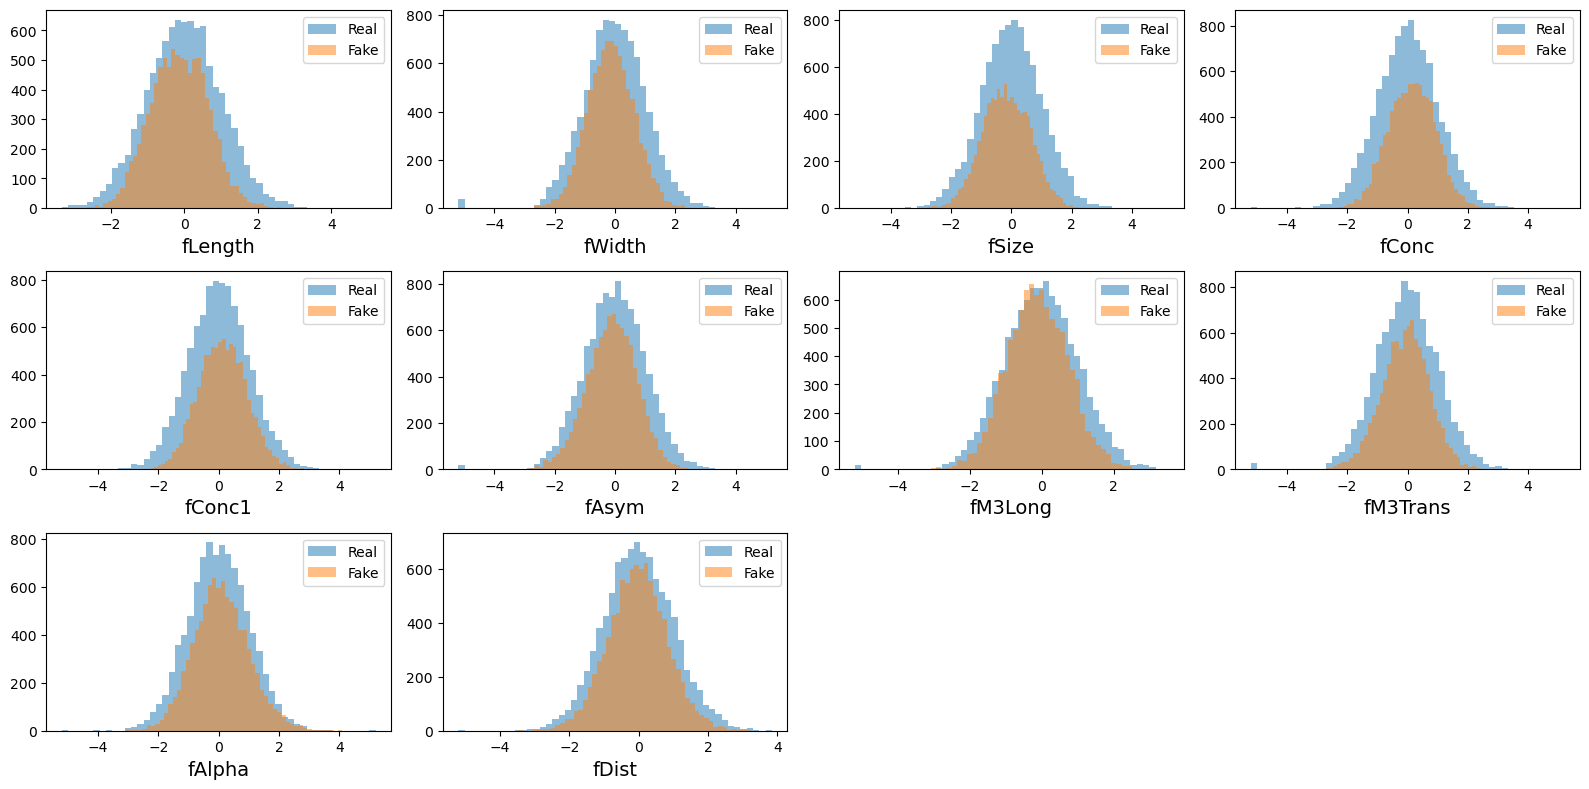

In [55]:
plot_hists(X_train, X_fake_train, label1="Real", label2="Fake", names=data_df.columns, bins=50)

In [56]:
X_fake_test = generate(vae_fitter.decoder, y_test, latent_dim)

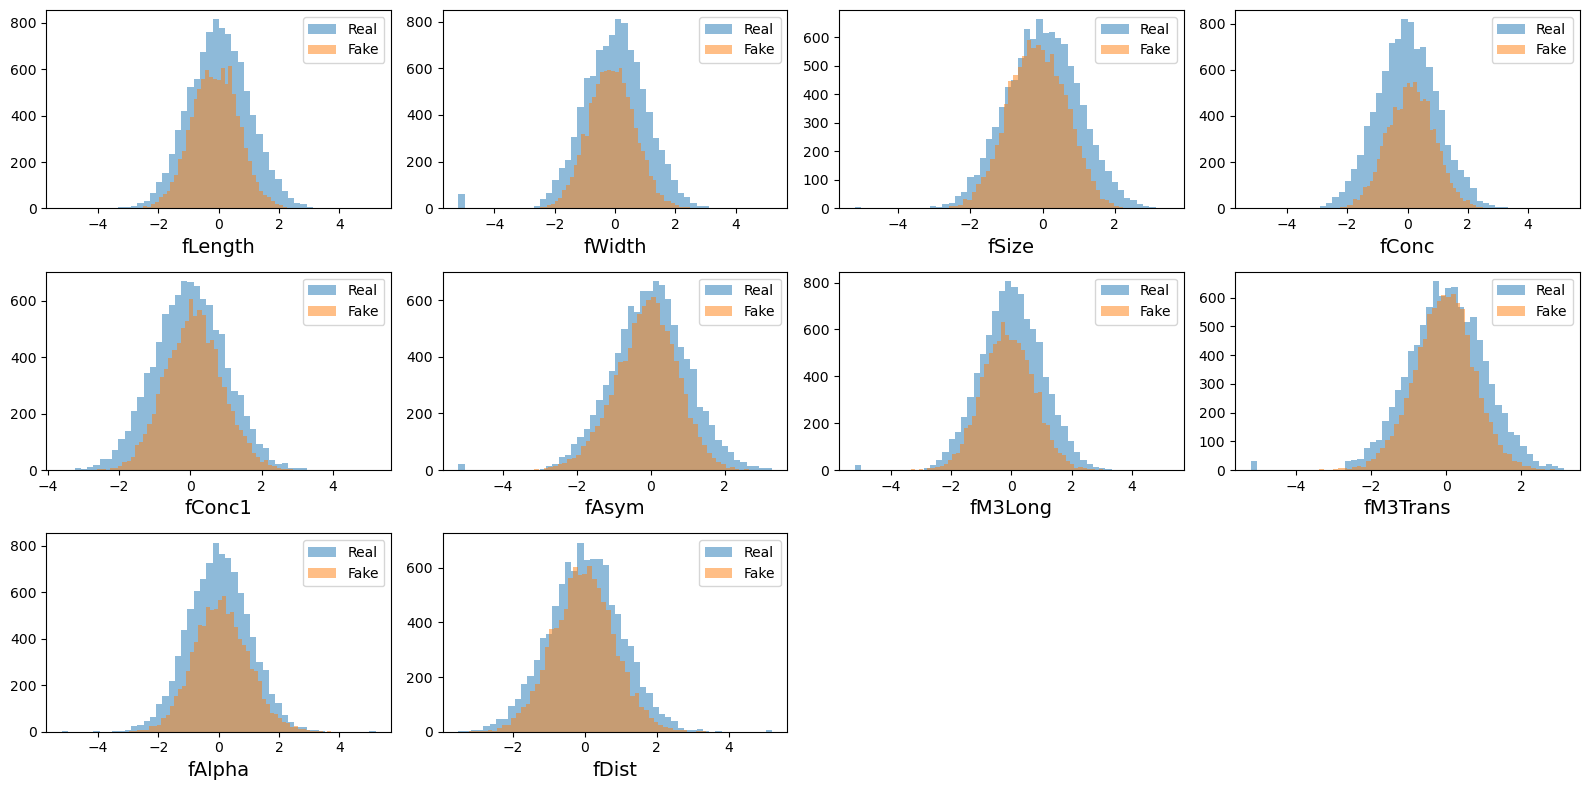

In [57]:
plot_hists(X_test, X_fake_test, label1="Real", label2="Fake", names=data_df.columns, bins=50)

In [58]:
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)
yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [59]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [60]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC (VAE) = ", auc)

ROC AUC (VAE) =  0.6962333632979176


## Задание 15

In [61]:
trainloader = torch.utils.data.DataLoader(X_train, batch_size=64, shuffle=True)

In [62]:
class NormalizingFlow(nn.Module):

    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()

        # Регистрируем слои как ModuleList чтобы PyTorch их видел
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_likelihood = None

        for layer in self.layers:
            x, change = layer.f(x)
            if log_likelihood is not None:
                log_likelihood = log_likelihood + change  # накапливаем log 
            else:
                log_likelihood = change  # первый слой

        # вероятность prior
        log_likelihood = log_likelihood + self.prior.log_prob(x)

        return log_likelihood.mean()

    def sample(self, num_samples):
        x = self.prior.sample((num_samples, ))

        for layer in self.layers[::-1]:
            x = layer.g(x)

        return x

## Задание 16

In [63]:
class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        self.mask = mask
        self.var_size = var_size

        # translation
        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
        )

        # scale
        self.nn_s = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
        )

    def f(self, x):
        x_masked = x * self.mask.to(x.device)

        t = self.nn_t(x_masked)
        s = self.nn_s(x_masked)
        new_x = x_masked + (1 - self.mask.to(x.device)) * (x * torch.exp(s) + t)
        log_det = (s * (1 - self.mask.to(x.device))).sum(dim=1)

        return new_x, log_det

    def g(self, x):
        x_masked = x * self.mask.to(x.device)

        t = self.nn_t(x_masked)
        s = self.nn_s(x_masked)
        new_x = x_masked + (1 - self.mask.to(x.device)) * (x - t) * torch.exp(-s)

        return new_x

In [64]:
def train_nf(trainloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []
    iter_i = 0

    for epoch_i in range(num_epochs):
        print(f'Epoch {epoch_i + 1}')
        for batch in trainloader:
            x = batch.float()

            opt.zero_grad()

            # Loss
            loss = -nf.log_prob(x)
            loss.backward()

            opt.step()

            loss_trace.append((iter_i, loss.item()))
            iter_i += 1

    return loss_trace

In [65]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    layers.append(RealNVP(var_size=10, mask=((torch.arange(10) + i) % 2)))

nf = NormalizingFlow(layers=layers, prior=prior)

opt = torch.optim.Adam(nf.parameters(), lr=1e-3)

In [66]:
train_nf(trainloader, nf, opt, num_epochs=10)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


[(0, 96.91218566894531),
 (1, 18.775745391845703),
 (2, 17.527408599853516),
 (3, 14.501441955566406),
 (4, 16.253978729248047),
 (5, 13.741952896118164),
 (6, 14.66700553894043),
 (7, 14.349245071411133),
 (8, 13.794185638427734),
 (9, 14.002260208129883),
 (10, 13.736201286315918),
 (11, 13.970684051513672),
 (12, 13.50158405303955),
 (13, 13.751392364501953),
 (14, 13.428473472595215),
 (15, 13.400705337524414),
 (16, 13.908136367797852),
 (17, 14.16489028930664),
 (18, 13.725422859191895),
 (19, 13.095560073852539),
 (20, 12.88564682006836),
 (21, 13.393695831298828),
 (22, 13.115360260009766),
 (23, 12.63186264038086),
 (24, 13.213385581970215),
 (25, 12.932270050048828),
 (26, 12.972216606140137),
 (27, 12.73600959777832),
 (28, 14.000754356384277),
 (29, 12.203006744384766),
 (30, 12.190918922424316),
 (31, 12.35009479522705),
 (32, 12.511117935180664),
 (33, 12.92330551147461),
 (34, 13.079798698425293),
 (35, 12.51017951965332),
 (36, 12.983826637268066),
 (37, 12.033318519592